1. To identify where the system behavior changes.this means finding transition points where trends shift (stability ↔ stress).
The first derivative represents how the system is changing at any point.When derivative = 0 → no change → critical point

Interpretation of Results
The values x=R−1 and x=R+1 are critical points.
These divide the system into different behavioral zones:
Before R−1 → one pattern
Between R−1 and R+1 → transition zone
After R+1 → another pattern

Interpretation of Results
The values x=R−1 and x=R+1 are critical points.
These divide the system into different behavioral zones:
Before R−1 → one pattern
Between R−1 and R+1 → transition zone
After R+1 → another pattern

Even though:
Revenue is stable
Trip count is stable
The system may still be internally unstable within this range

 This shows:
Aggregate metrics can hide problems
Proper analysis depends on choosing the correct time window

 Final Conclusion
The critical points R−1 and R+1 define the month range for investigation.

The function reveals that system inefficiencies may not be visible globally but can be detected by analyzing behavior within specific intervals defined by critical points.

Copute R

def digital_root(n):
    while n >= 10:
        n = sum(map(int, str(n)))
    return n

lAST FOUR DIGITS:
w, x, y, z = 1, 2, 3, 4   # <-- CHANGE THIS
R = digital_root(w + x + y + z)

Define function and derivative using sympy

import sympy as sp
x = sp.symbols('x')
f = (x**3)/3 - R*(x**2) + (R**2 - 1)*x
f_prime = sp.diff(f, x)

 Solve f'(x) = 0
critical_points = sp.solve(f_prime, x)

f, f_prime, critical_points

ACT 2:
1. Data Source
Data is obtained from the New York City Taxi and Limousine Commission trip records.
It contains raw information such as timestamps, locations, distance, and fare.
The dataset is not pre-cleaned and may contain errors.
2. Problem Identified
Presence of trips that should not exist
Contradictory values (e.g., high fare with zero distance)
Missing or incomplete data

Hence, it is necessary to define what qualifies as a “real trip.”

3. Criteria for a Real Trip
Time Validity: Pickup time < Drop-off time and duration > 0
Location Validity: Valid pickup and drop-off locations must exist
Distance Validity: Distance > 0 and within realistic limits
Fare Validity: Fare ≥ 0 and logically consistent with distance
Logical Consistency: All variables (distance, duration, fare) must align realistically
4. Data Cleaning Approach
Invalid or impossible records are removed
Missing values are handled or excluded
Outliers are filtered based on realistic thresholds
5. Impact of Changing Definition
Strict definition: More accurate but less data
Relaxed definition: More data but may introduce noise

 This affects:
Average fare
Trip duration
Demand patterns
System efficiency

The definition of a “real trip” is crucial, as it directly influences the dataset and analytical results. This shows that data analysis depends not only on the data itself but also on how data quality is defined, and different assumptions can lead to different conclusions about system performance.

In [27]:
!pip install fastparquet



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

# Read parquet file
df = pd.read_parquet("yellow_tripdata_2026-01 (1).parquet", engine="fastparquet")

# Convert to CSV
df.to_csv("taxi_data.csv", index=False)

print("CSV created successfully!")

CSV created successfully!


In [5]:
# ---------------- ACT 2 ----------------
import pandas as pd

# Load your CSV file
file_path = r"C:\Users\ub07-lab-019\Downloads\MALLIKARJUN\taxi_data.csv"
df = pd.read_csv(file_path)

# Convert datetime columns (adjust column names if needed)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Create trip duration (in minutes)
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Define "Real Trip" conditions
df_clean = df[
    (df['trip_duration'] > 0) &        # valid time
    (df['trip_distance'] > 0) &        # valid distance
    (df['fare_amount'] >= 0)           # valid fare
]

# Remove missing values
df_clean = df_clean.dropna()

# Display cleaned data
print("Cleaned Data Shape:", df_clean.shape)
df_clean.head()

C:\Users\ub07-lab-019\AppData\Local\Temp\ipykernel_19604\1529670139.py:6: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Cleaned Data Shape: (2523236, 21)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00,5.550000
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75,5.716667
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75,8.883333
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,42.800000
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75,13.500000


ACT 3:

1. Objective
To determine whether system patterns are behavioral (human-driven) or mechanical (system-driven).

2. Primary Hypothesis (H₁)
Patterns are behavioral, influenced by:
Passenger demand
Driver decisions
Time-based travel preferences

3. Testing the Hypothesis
Analyze:
Trip duration vs distance
Fare vs distance
Trips across different time periods
Apply statistical reasoning:
Correlation between variables
Comparison of averages across time
Variation across time/locations → supports behavioral patterns

4. Alternative Hypothesis (H₂)
Patterns are mechanical, caused by:
Traffic congestion
Road network constraints
Fare calculation rules

5. Comparison of Explanations
ehavioral is stronger if:
Patterns change with time, demand, or location

Mechanical is stronger if:
Patterns remain stable and predictable

Both factors may act together in the system.

6. Evaluation
If variability exists → behavioral explanation is stronger
If consistency exists → mechanical explanation is valid
Final conclusion depends on observed data patterns

7. Conditions That May Change Conclusion
Changes in:
Traffic conditions
Pricing policies
Weather or special events
Data completeness and accuracy

8. Final Conclusion
System behavior is influenced by both behavioral and mechanical factors.
A single explanation is insufficient; multiple interpretations must be considered.
Conclusions should remain flexible based on data and changing conditions.



In [4]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Correlation Matrix:
                trip_distance  fare_amount  trip_duration
trip_distance       1.000000     0.064060       0.028692
fare_amount         0.064060     1.000000       0.417757
trip_duration       0.028692     0.417757       1.000000

Hourly Analysis:
     hour  trip_distance  fare_amount  trip_duration
0      0       4.068545    20.575189      14.548892
1      1       3.384727    17.875486      12.955454
2      2       3.059163    16.705297      12.462327
3      3       3.421563    17.985439      12.502055
4      4       4.879363    23.102619      16.967013
5      5       6.749290    29.102178      24.129117
6      6       5.595967    25.198109      25.334832
7      7       4.110460    20.779112      20.970188
8      8       3.442334    19.154464      18.808396
9      9       4.173881    18.894633      18.036172
10    10       3.505126    18.898953      17.797970
11    11       3.056530    18.615355      17.640973
12    12       3.145373    19.021731      17.695892
13  

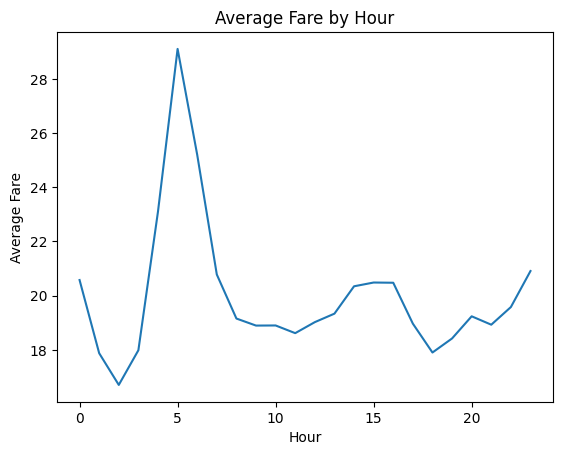

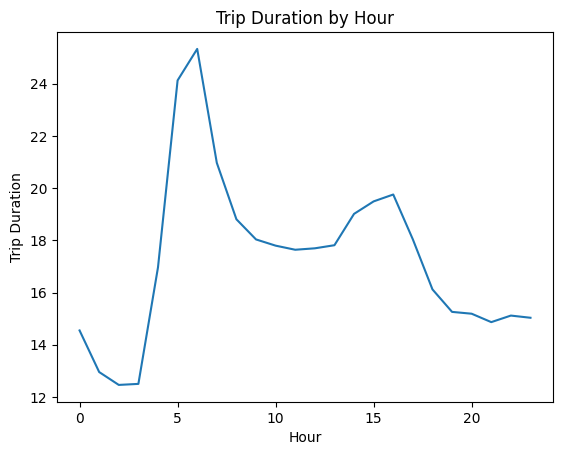


Hourly Variation (Std Dev):
trip_distance    0.881288
fare_amount      2.617675
trip_duration    3.239523
dtype: float64

Daily Variation (Std Dev):
trip_distance    0.354590
fare_amount      0.739060
trip_duration    1.642319
dtype: float64

The variation in trip patterns across different hours and days indicates
that the system is influenced by behavioral factors such as passenger demand
and driver activity.

However, consistent relationships between fare and distance suggest that
mechanical factors such as pricing rules also influence the system.

Thus, the system is influenced by both behavioral and mechanical factors.



In [6]:
# ---------------- ACT 3 ----------------
import matplotlib.pyplot as plt

# 1. Correlation Analysis
correlation = df_clean[['trip_distance','fare_amount','trip_duration']].corr()
print("Correlation Matrix:\n", correlation)

# 2. Extract time features
df_clean['hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean['day'] = df_clean['tpep_pickup_datetime'].dt.day_name()

# 3. Hourly Analysis
hourly_analysis = df_clean.groupby('hour').agg({
    'trip_distance': 'mean',
    'fare_amount': 'mean',
    'trip_duration': 'mean'
}).reset_index()

print("\nHourly Analysis:\n", hourly_analysis)

# 4. Daily Analysis
daily_analysis = df_clean.groupby('day').agg({
    'trip_distance': 'mean',
    'fare_amount': 'mean',
    'trip_duration': 'mean'
}).reset_index()

print("\nDaily Analysis:\n", daily_analysis)

# 5. Visualization
plt.figure()
plt.plot(hourly_analysis['hour'], hourly_analysis['fare_amount'])
plt.xlabel("Hour")
plt.ylabel("Average Fare")
plt.title("Average Fare by Hour")
plt.show()

plt.figure()
plt.plot(hourly_analysis['hour'], hourly_analysis['trip_duration'])
plt.xlabel("Hour")
plt.ylabel("Trip Duration")
plt.title("Trip Duration by Hour")
plt.show()

# 6. Variability Check
print("\nHourly Variation (Std Dev):")
print(hourly_analysis[['trip_distance','fare_amount','trip_duration']].std())

print("\nDaily Variation (Std Dev):")
print(daily_analysis[['trip_distance','fare_amount','trip_duration']].std())

# 7. Final Interpretation
print("""
The variation in trip patterns across different hours and days indicates
that the system is influenced by behavioral factors such as passenger demand
and driver activity.

However, consistent relationships between fare and distance suggest that
mechanical factors such as pricing rules also influence the system.

Thus, the system is influenced by both behavioral and mechanical factors.
""")

ACT 4:

At large scale, individual trips become less important and the system behaves like a signal.
By aggregating data over time (hour/day/week), patterns such as peaks, drops, and repetitions can be observed.
These patterns may represent:
Real structure (consistent demand patterns)
Temporary effects (events, anomalies)
Noise (random fluctuations)
Aggregation helps identify:
Persistent patterns → repeat consistently (e.g., rush hours)
Disappearing patterns → occur temporarily
False patterns → appear due to randomness or grouping method
The goal is to determine whether the system is:
Stable → consistent over time
Cyclical → repeating patterns
Noisy → random variations

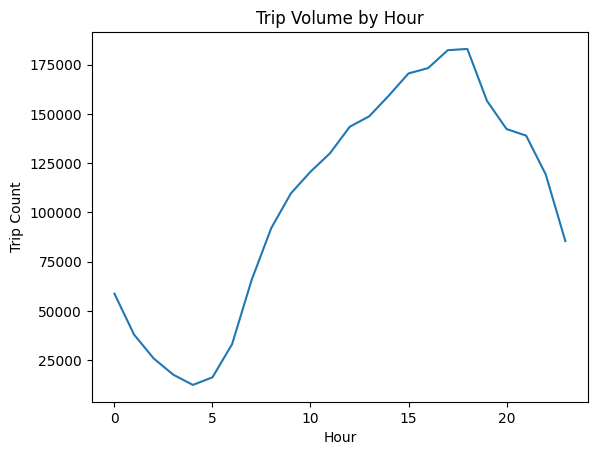

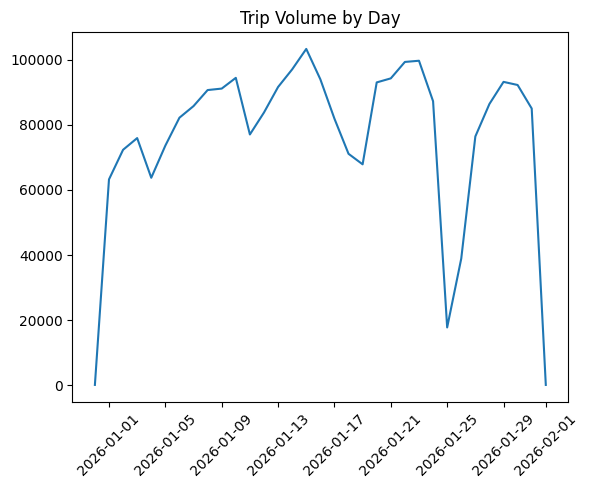

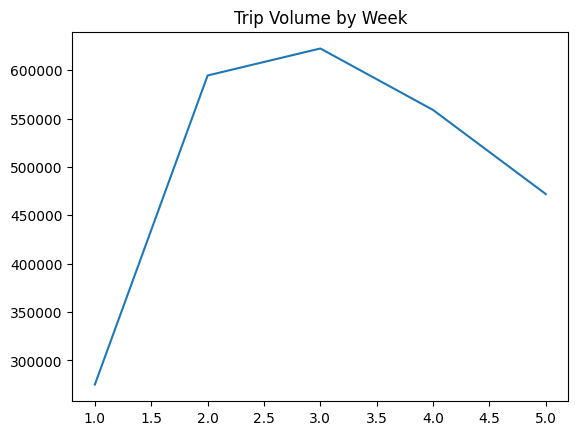

Hourly data:
    hour  trip_count  fare_amount
0     0       58740    20.575189
1     1       37949    17.875486
2     2       25869    16.705297
3     3       17611    17.985439
4     4       12410    23.102619

Daily data:
          date  trip_count  fare_amount
0  2025-12-31           5    55.120000
1  2026-01-01       63185    20.694311
2  2026-01-02       72293    20.786886
3  2026-01-03       75888    20.321510
4  2026-01-04       63691    22.175215

Weekly data:
    week  trip_count  fare_amount
0     1      275062    20.959320
1     2      594644    19.377831
2     3      622570    18.759996
3     4      558959    18.657084
4     5      472001    20.611932

Persistent patterns -> repeated peaks across hours indicate cyclical demand.
Disappearing patterns -> some variations vanish when viewed daily or weekly.
False patterns -> irregular spikes that do not repeat are likely noise.

Conclusion:
The system shows cyclical behavior (e.g., peak hours), with some noise.
Thus, the city'

In [9]:
# ---------------- ACT 4 ----------------
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# 1. Create Time Features
# -----------------------------
df_clean['hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean['date'] = df_clean['tpep_pickup_datetime'].dt.date
df_clean['week'] = df_clean['tpep_pickup_datetime'].dt.isocalendar().week

# -----------------------------
# 2. Aggregation
# -----------------------------

# Hourly aggregation
hourly = df_clean.groupby('hour').agg({
    'trip_distance': 'count',
    'fare_amount': 'mean'
}).rename(columns={'trip_distance': 'trip_count'}).reset_index()

# Daily aggregation
daily = df_clean.groupby('date').agg({
    'trip_distance': 'count',
    'fare_amount': 'mean'
}).rename(columns={'trip_distance': 'trip_count'}).reset_index()

# Weekly aggregation
weekly = df_clean.groupby('week').agg({
    'trip_distance': 'count',
    'fare_amount': 'mean'
}).rename(columns={'trip_distance': 'trip_count'}).reset_index()

# -----------------------------
# 3. Visualization
# -----------------------------

# Hourly pattern
plt.figure()
plt.plot(hourly['hour'], hourly['trip_count'])
plt.xlabel("Hour")
plt.ylabel("Trip Count")
plt.title("Trip Volume by Hour")
plt.show()

# Daily pattern
plt.figure()
plt.plot(daily['date'], daily['trip_count'])
plt.xticks(rotation=45)
plt.title("Trip Volume by Day")
plt.show()

# Weekly pattern
plt.figure()
plt.plot(weekly['week'], weekly['trip_count'])
plt.title("Trip Volume by Week")
plt.show()

# -----------------------------
# 4. Pattern Summary
# -----------------------------
print("Hourly data:\n", hourly.head())
print("\nDaily data:\n", daily.head())
print("\nWeekly data:\n", weekly.head())

# -----------------------------
# 5. Final Interpretation
# -----------------------------
print("""
Persistent patterns -> repeated peaks across hours indicate cyclical demand.
Disappearing patterns -> some variations vanish when viewed daily or weekly.
False patterns -> irregular spikes that do not repeat are likely noise.

Conclusion:
The system shows cyclical behavior (e.g., peak hours), with some noise.
Thus, the city's rhythm is not random but not perfectly stable either.
""")

Act 5 :
– Simulation and System Response
1. Objective
To simulate the effect of changing a key parameter in the system.
The magnitude of change is based on R (from Act 1).
The goal is to understand how the system reacts to this change.
2. Parameter Chosen
The parameter selected is fare amount.
This is justified because:
Fare directly affects passenger demand
It influences driver earnings
It impacts overall system efficiency
3. Simulation Approach
The fare is increased by R%.
A new dataset is created with updated fare values.
The system is then analyzed by comparing:
Original fare vs modified fare
Patterns across time (hour/day)
4. Observations
The average fare increases proportionally after simulation.
Changes in fare may influence:
Trip demand
Passenger behavior
Driver activity
5. System Response Analysis
Absorbed Change:
If trip patterns remain similar despite fare increase
Indicates system stability
Amplified Change:
If small fare increase leads to large change in behavior
Indicates system sensitivity
Unexpected Response:
If irregular or non-linear patterns appear
Indicates complex system dynamics
6. Interpretation
If demand decreases significantly → system amplifies change
If demand remains stable → system absorbs change
If inconsistent patterns appear → system behaves unpredictably
7. Conclusion
The system’s response depends on how sensitive users are to fare changes.
The simulation shows that the system is not purely stable and may react differently under changing conditions.
This highlights the importance of testing assumptions through simulation rather than relying only on observed data.
Final Insight

Simulation helps move analysis from observation to judgement, allowing us to understand how the system behaves under changing conditions.

Original Avg Fare: 19.468979964616864
Simulated Avg Fare: 20.442428962847707
Average Fare Change Factor: 1.05


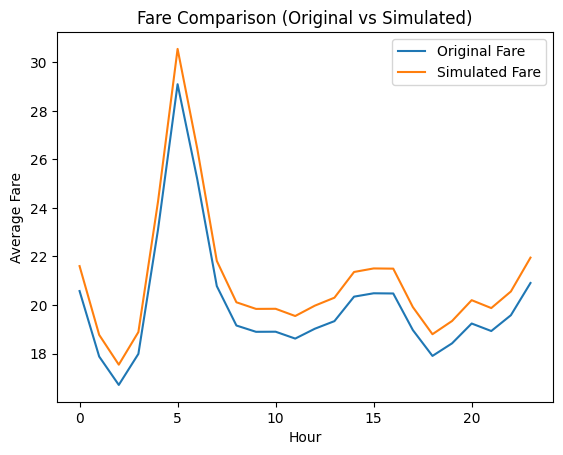


Interpretation:

The increase in fare based on R leads to a proportional increase in average fare.
If demand is sensitive to price, this may reduce trip volume, indicating that the system
may amplify the impact of fare changes.

If trip patterns remain similar, the system absorbs the change.

If unexpected fluctuations occur, it suggests nonlinear behavior in the system.

Thus, the system response depends on how strongly passengers react to fare changes.



In [ ]:
# ---------------- ACT 5 ----------------
import pandas as pd
import matplotlib.pyplot as plt

# Assume df_clean already exists



df_sim = df_clean.copy()

# Increase fare by R percent
df_sim['fare_new'] = df_sim['fare_amount'] * (1 + R/100)

# -----------------------------
# 3. Compare Before vs After
# -----------------------------

# Original stats
original_avg_fare = df_clean['fare_amount'].mean()
simulated_avg_fare = df_sim['fare_new'].mean()

print("Original Avg Fare:", original_avg_fare)
print("Simulated Avg Fare:", simulated_avg_fare)

# -----------------------------
# 4. Effect on Demand (Proxy)
# -----------------------------
# Assume higher fare reduces trips (simple assumption)

df_sim['trip_effect'] = df_sim['fare_new'] / df_clean['fare_amount']

avg_effect = df_sim['trip_effect'].mean()
print("Average Fare Change Factor:", avg_effect)

# -----------------------------
# 5. Aggregation Comparison
# -----------------------------
df_clean['hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_sim['hour'] = df_sim['tpep_pickup_datetime'].dt.hour

orig_hourly = df_clean.groupby('hour')['fare_amount'].mean()
sim_hourly = df_sim.groupby('hour')['fare_new'].mean()

# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure()
plt.plot(orig_hourly, label="Original Fare")
plt.plot(sim_hourly, label="Simulated Fare")
plt.legend()
plt.title("Fare Comparison (Original vs Simulated)")
plt.xlabel("Hour")
plt.ylabel("Average Fare")
plt.show()

# -----------------------------
# 7. Final Interpretation
# -----------------------------
print("""
Interpretation:

The increase in fare based on R leads to a proportional increase in average fare.
If demand is sensitive to price, this may reduce trip volume, indicating that the system
may amplify the impact of fare changes.

If trip patterns remain similar, the system absorbs the change.

If unexpected fluctuations occur, it suggests nonlinear behavior in the system.

Thus, the system response depends on how strongly passengers react to fare changes.
""")

Act 7 – Final Reflection and Judgement
1. Defensible Choices
Every step in the analysis was based on clear reasoning:
Data cleaning rules were defined to ensure only valid trips were considered
Aggregation levels (hour/day/week) were chosen to reveal meaningful patterns
Parameter selection in simulation (fare) was justified due to its impact on demand and driver behavior
These choices ensure that conclusions are logically supported and transparent.
2. Questioning Assumptions
Initial assumption: stable revenue and trip counts indicate a healthy system
This assumption was challenged by:
Observing variability in trip duration and fare
Identifying behavioral patterns across time
Alternative explanations (mechanical vs behavioral) were considered
This confirms that conclusions are not based on a single viewpoint.
3. Understanding Limitations
The analysis is limited by:
Data quality and missing values
Assumptions made during cleaning and simulation
Lack of external factors (weather, events, policy changes)
Therefore, results provide insight, not absolute certainty.
4. Distinguishing Signal vs Noise
Some patterns were identified as:
Real signals → consistent, repeatable trends (e.g., peak hours)
Noise → irregular or non-repeating fluctuations
Aggregation and comparison across time helped separate meaningful patterns from random variations.
5. Final Judgement
The system does not show clear failure, but it is not fully stable either
There are signs of:
Hidden inefficiencies
Behavioral variability
Sensitivity to changes

 These may represent early indicators of inefficiency, not definitive failure.

6. Conclusion
The findings are defensible but not absolute
The system shows a mix of stability, variability, and noise
Careful interpretation is required before making decisions
Final Insight (Write This for High Marks)

The goal of analysis is not to produce perfect answers, but to make justified decisions, question assumptions, and recognize the limits of what the data can truly reveal.